# National AI Strategy — Text Analysis (CN, DE, FR, IT, US)

Comparative text analysis of 5 National AI Strategy documents:

- `CN_National_AI_Strategy.pdf` — China
- `DE_National_AI_Strategy.pdf` — Germany
- `FR__National_AI_Strategy.pdf` — France
- `IT_National_AI_Strategy.pdf` — Italy
- `US_National_AI_Strategy.pdf` — United States

Located in [`data/pdf/AI Policy/`](../../data/pdf/AI%20Policy/).

## Required Packages

```bash
pip install pdfplumber scikit-learn matplotlib pandas seaborn plotly ipywidgets wordcloud nltk
```


## 1. Setup

In [7]:
from pathlib import Path
import re
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import pdfplumber
import gdown

from sklearn.feature_extraction.text import (
    TfidfVectorizer,
    CountVectorizer
)

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import LatentDirichletAllocation

plt.rcParams['axes.unicode_minus'] = False


# =========================================================
# Find Repository Root
# =========================================================
def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'data').is_dir():
            return p

    raise FileNotFoundError(
        'Could not locate repo root containing `data/`'
    )


repo_root = find_repo_root(Path.cwd())


# # =========================================================
# # Google Drive Download Config
# # =========================================================
# DRIVE_FOLDER_URL = "https://drive.google.com/drive/folders/1CCiBmppafwtXLRVTpnryIY8Y9PLvxwvG"

# download_dir = (
#     repo_root
#     / 'data'
#     / 'pdf'
#     / 'AI Policy'
# )

# download_dir.mkdir(
#     parents=True,
#     exist_ok=True
# )


# # =========================================================
# # Download PDFs from Google Drive
# # =========================================================
# print("=" * 60)
# print("Downloading PDFs from Google Drive...")
# print("=" * 60)

# try:
#     gdown.download_folder(
#         url=DRIVE_FOLDER_URL,
#         output=str(download_dir),
#         quiet=False,
#         use_cookies=False
#     )

#     print("\nDownload completed.")

# except Exception as e:
#     print(f"\nDownload failed: {e}")


# # =========================================================
# # Locate PDF Directory
# # =========================================================
pdf_dir = repo_root / 'data' / 'pdf' / 'AI Policy'

pdf_files = list(pdf_dir.glob("*.pdf"))


# =========================================================
# Display Information
# =========================================================
print("\n" + "=" * 60)
print("Repository Information")
print("=" * 60)

print(f"Repo root : {repo_root}")
print(f"PDF dir   : {pdf_dir}")
print(f"PDF count : {len(pdf_files)}")

print("\nPDF Files:")
for pdf in pdf_files:
    print(f" - {pdf.name}")


Repository Information
Repo root : /home/wucheng/AI-Policy
PDF dir   : /home/wucheng/AI-Policy/data/pdf/AI Policy
PDF count : 5

PDF Files:
 - IT_National_AI_Strategy.pdf
 - US_National_AI_Strategy.pdf
 - FR__National_AI_Strategy.pdf
 - DE_National_AI_Strategy.pdf
 - CN_National_AI_Strategy.pdf


## 2. Country Mapping

In [8]:
COUNTRY_MAP = {
    'CN_National_AI_Strategy.pdf':  'China',
    'DE_National_AI_Strategy.pdf':  'Germany',
    'FR__National_AI_Strategy.pdf': 'France',
    'IT_National_AI_Strategy.pdf':  'Italy',
    'US_National_AI_Strategy.pdf':  'United States',
}

COLORS = {
    'China':         '#d62728',
    'Germany':       '#8c564b',
    'France':        '#9467bd',
    'Italy':         '#e377c2',
    'United States': '#1f77b4',
}


def country_subplot_grid(n_items, n_cols=3, row_height=4.8):
    """Create enough subplots for the available strategy documents."""
    n_rows = int(np.ceil(n_items / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.2 * n_cols, row_height * n_rows))
    axes = np.atleast_1d(axes).flatten()
    for ax in axes[n_items:]:
        ax.set_visible(False)
    return fig, axes[:n_items]


## 3. Extract Text from PDFs

Uses `pdfplumber`. Returns a dict `{country: full_text}`.


In [9]:
def extract_pdf_text(path: Path) -> str:
    pages = []
    with pdfplumber.open(path) as pdf:
        for page in pdf.pages:
            t = page.extract_text() or ''
            pages.append(t)
    return '\n'.join(pages)


texts = {}
page_counts = {}

for pdf_path in sorted(pdf_dir.glob('*.pdf')):
    country = COUNTRY_MAP.get(pdf_path.name, pdf_path.stem)
    text = extract_pdf_text(pdf_path)
    texts[country] = text
    with pdfplumber.open(pdf_path) as p:
        page_counts[country] = len(p.pages)
    print(f'{country:15s}  {page_counts[country]:>4d} pages, {len(text):>8,} chars')


China              18 pages,   27,582 chars
Germany            31 pages,  101,100 chars
France             30 pages,   42,286 chars
Italy              38 pages,  127,506 chars
United States      28 pages,   68,711 chars


## 4. Document Statistics

In [10]:
def word_tokenize(text: str) -> list:
    """Lowercase tokens of letters only (length >= 3)."""
    return re.findall(r"[a-zA-Zà-ÿÀ-ÝäöüÄÖÜß']{3,}", text.lower())


stats = []
for country, text in texts.items():
    tokens = word_tokenize(text)
    stats.append({
        'Country': country,
        'Pages': page_counts[country],
        'Characters': len(text),
        'Words (>=3 chars)': len(tokens),
        'Unique words': len(set(tokens)),
        'Type-token ratio': round(len(set(tokens)) / max(len(tokens), 1), 3),
    })

stats_df = pd.DataFrame(stats).set_index('Country')
print('Document statistics:')
stats_df


Document statistics:


,Pages,Characters,Words (>=3 chars),Unique words,Type-token ratio
Country,,,,,
China,18,27582,3214,966,0.301
Germany,31,101100,11608,2059,0.177
France,30,42286,4870,1622,0.333
Italy,38,127506,14917,2986,0.200
United States,28,68711,7756,1905,0.246


## 5. Build a Stopword List (multilingual)

In [11]:
# Combined stopword list for EN, DE, FR, IT
EN_STOP = set('the a an and or but if is are was were be been being have has had do does did the of in to for on with at from by as it its this that these those we our us i you he she they them their there here can will would should may might shall must not no yes also more most some any all each every other another such own same so than then thus too very into over under between among through during before after above below upon out off down up'.split())
DE_STOP = set('der die das den dem des ein eine einen einer eines einem auch aber als alle alles am an auf aus bei bin bis dann dass dem den der des deshalb dich die dies dir doch dort durch ein eine einen einer eines er es etwas für gegen gewesen habe haben hatten hier ich ihm ihn ihnen ihre im in ins ist ja jede jeden jeder jedes jenen jener jenes kann kein keine keinen keiner keines könne konnten machen man mehr mit nach nicht noch nur ob oder ohne sehr sein seine sich sie sind so soll soweit sowie über um und uns unser unsere von vor war waren was weg wegen weil welche welchen welcher welches wenn wer werde werden wie wieder wir wird wirst wo woher wohin zu zum zur zwar zwischen'.split())
FR_STOP = set('le la les un une des de du au aux dans sur par pour avec sans sous chez ce cette ces cet est sont ai as a avons avez ont être étant été être avoir étant et ou mais donc car ne pas plus moins très tout tous toute toutes même mêmes je tu il elle ils elles nous vous mon ma mes ton ta tes son sa ses notre nos votre vos leur leurs qui que quoi dont où quand comment combien si lors lorsqu pourquoi quel quelle quels quelles ainsi alors aussi cela ceci celui celle ceux celles encore dès lors qu en y'.split())
IT_STOP = set('il lo la i gli le un uno una di a da in con su per tra fra che cui chi cui dove come quando perché poiché mentre se ma anche ed ebbe è sono sei siamo siete è anch ancora dopo prima durante questo questa questi queste quel quello quella quei quegli quelle non si suo sua suoi sue mio mia miei mie tuo tua tuoi tue nostro nostra nostri nostre vostro vostra vostri vostre loro essere avere fare detto fatto altri altre altro essere stato sopra sotto dentro fuori molto poco più meno tutto tutti tutta tutte ogni ognuno ogniuno entrambi quale quali alcuni alcune'.split())

ALL_STOP = EN_STOP | DE_STOP | FR_STOP | IT_STOP
# Common PDF/document artifacts
ALL_STOP |= {'pdf', 'page', 'fig', 'figure', 'table', 'www', 'http', 'https', 'com', 'org',
             'eu', 'usa', 'uk', 'nan', 'see', 'shall', 'use', 'used', 'using', 'use'}
print(f'Stopwords total: {len(ALL_STOP)}')


Stopwords total: 425


## 6. Top Words per Country (Frequency)

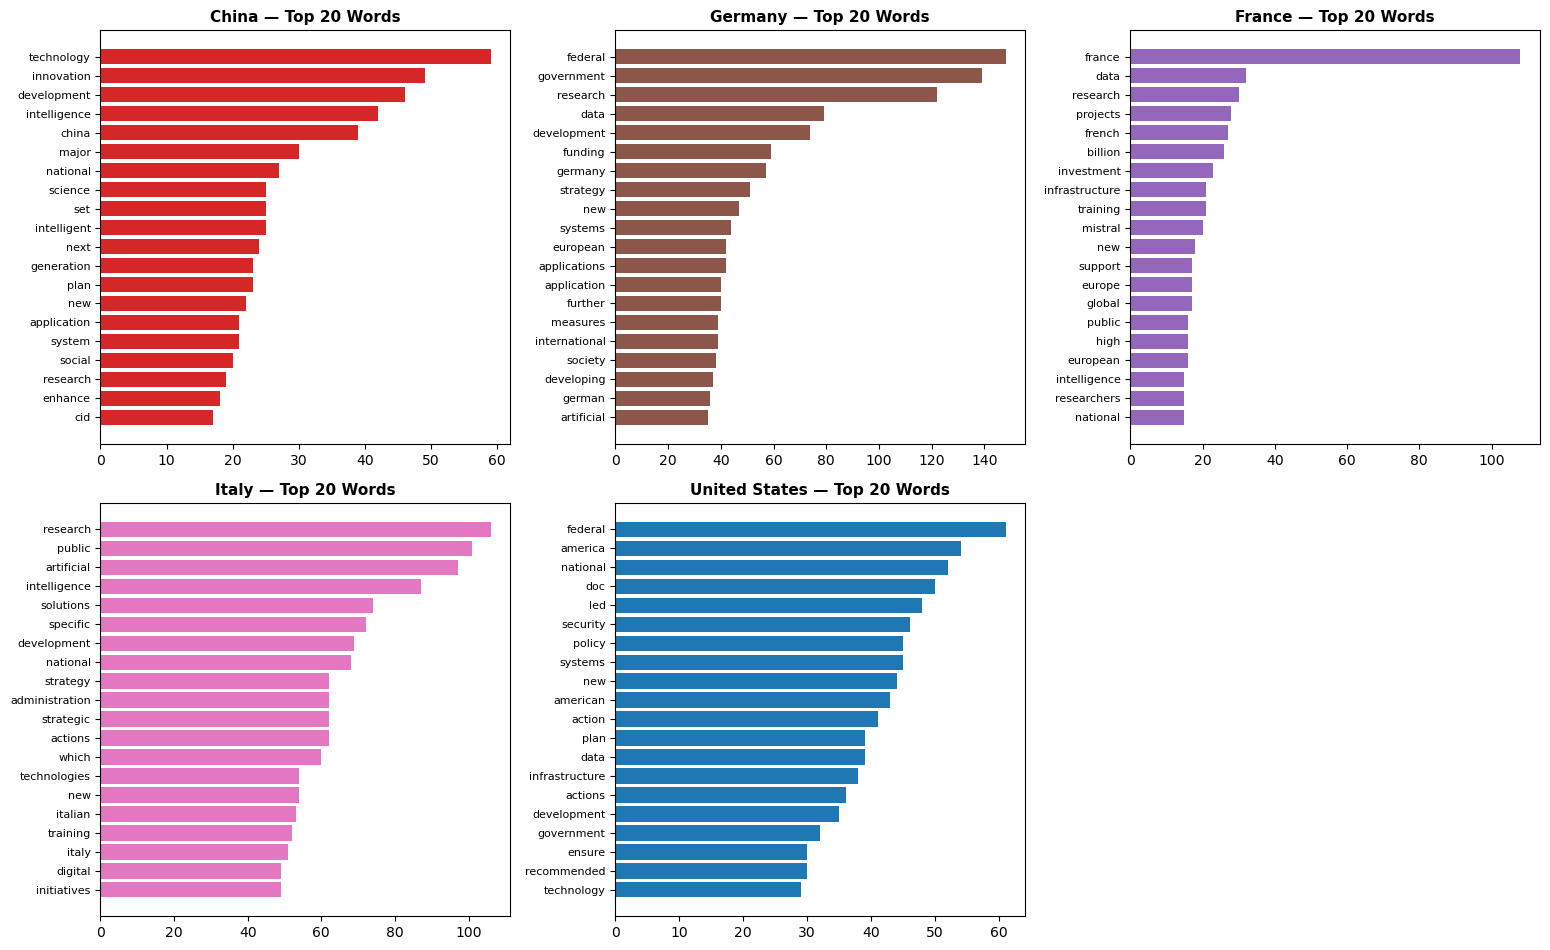

In [12]:
def top_words(text, n=25):
    tokens = [t for t in word_tokenize(text) if t not in ALL_STOP]
    return Counter(tokens).most_common(n)


fig, axes = country_subplot_grid(len(texts), n_cols=3)

for ax, (country, text) in zip(axes, texts.items()):
    top = top_words(text, n=20)
    words = [w for w, _ in top][::-1]
    counts = [c for _, c in top][::-1]
    ax.barh(words, counts, color=COLORS[country])
    ax.set_title(f'{country} — Top 20 Words', fontsize=11, fontweight='bold')
    ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()


## 7. TF-IDF — What's Distinctive About Each Country?

TF-IDF identifies words that are *unusually frequent* in one document relative to the others.


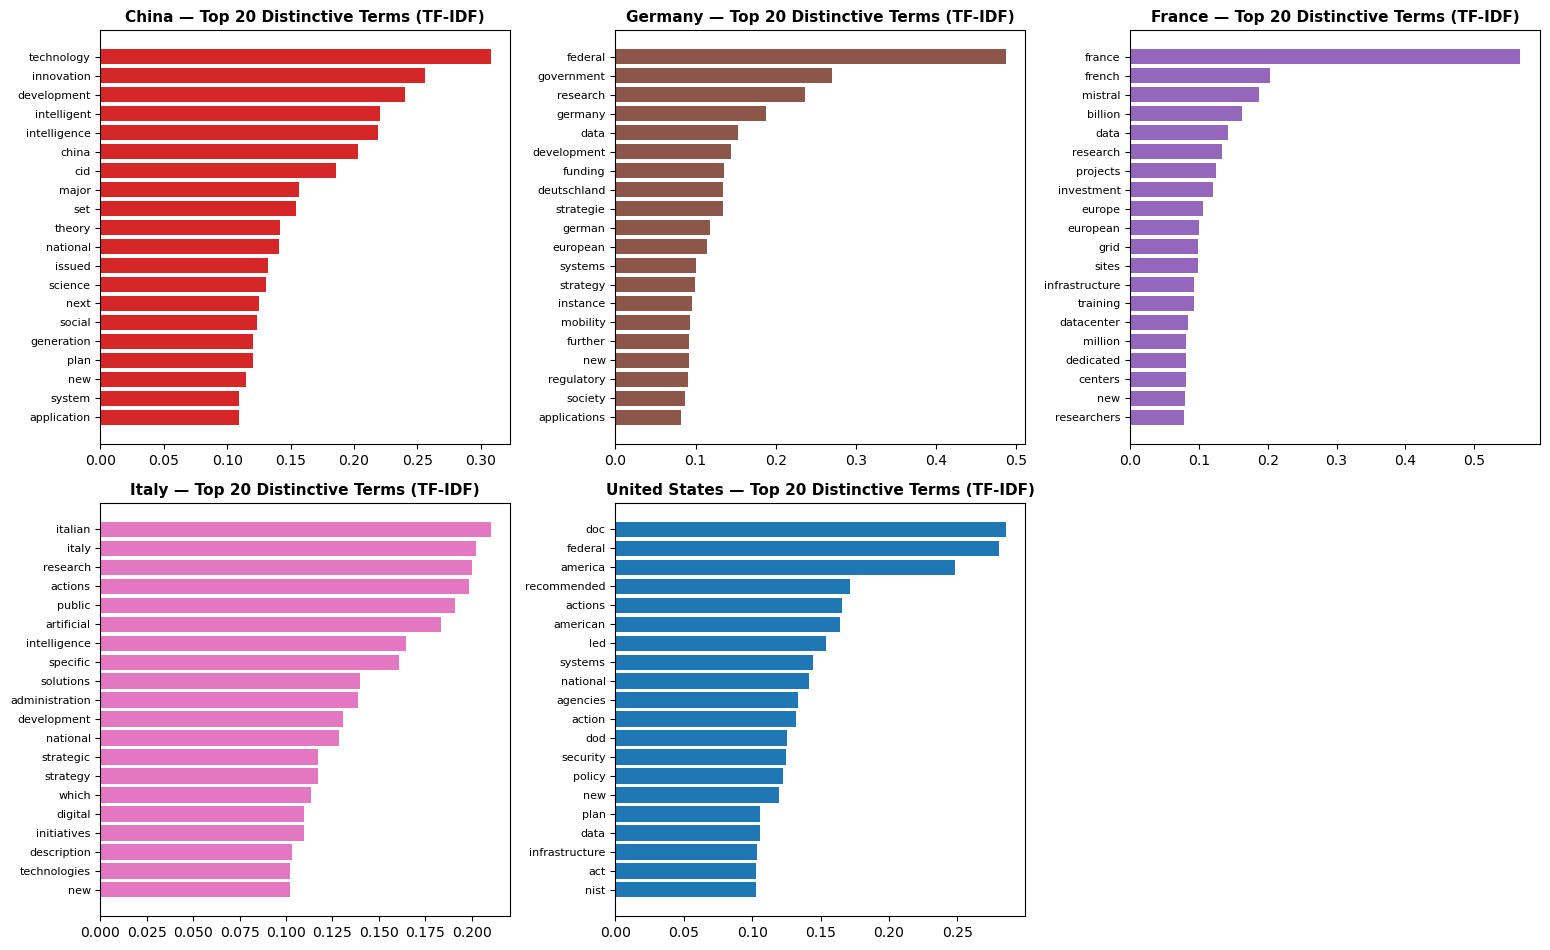

In [13]:
docs = [texts[c] for c in texts.keys()]
countries = list(texts.keys())

vec = TfidfVectorizer(
    stop_words=list(ALL_STOP),
    token_pattern=r"[a-zA-Zà-ÿÀ-ÝäöüÄÖÜß']{3,}",
    max_features=2000,
    lowercase=True,
)
tfidf = vec.fit_transform(docs)
vocab = vec.get_feature_names_out()

# Top distinctive words per country
fig, axes = country_subplot_grid(len(countries), n_cols=3)

for ax, (i, country) in zip(axes, enumerate(countries)):
    row = tfidf[i].toarray().flatten()
    top_idx = row.argsort()[-20:][::-1]
    words = [vocab[j] for j in top_idx][::-1]
    scores = [row[j] for j in top_idx][::-1]
    ax.barh(words, scores, color=COLORS[country])
    ax.set_title(f'{country} — Top 20 Distinctive Terms (TF-IDF)',
                 fontsize=11, fontweight='bold')
    ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()


## 8. Document Similarity (Cosine on TF-IDF)

How similar are the strategies to one another?


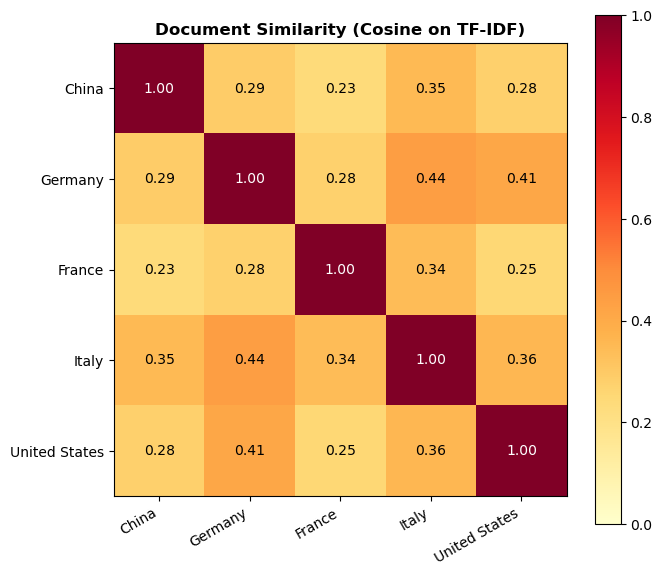

,China,Germany,France,Italy,United States
China,1.000,0.290,0.235,0.350,0.278
Germany,0.290,1.000,0.276,0.438,0.413
France,0.235,0.276,1.000,0.342,0.253
Italy,0.350,0.438,0.342,1.000,0.358
United States,0.278,0.413,0.253,0.358,1.000


In [14]:
sim_matrix = cosine_similarity(tfidf)
sim_df = pd.DataFrame(sim_matrix, index=countries, columns=countries).round(3)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(sim_df.values, cmap='YlOrRd', vmin=0, vmax=1)
ax.set_xticks(range(len(countries)))
ax.set_xticklabels(countries, rotation=30, ha='right')
ax.set_yticks(range(len(countries)))
ax.set_yticklabels(countries)
ax.set_title('Document Similarity (Cosine on TF-IDF)', fontweight='bold')

for i in range(len(countries)):
    for j in range(len(countries)):
        ax.text(j, i, f'{sim_df.values[i,j]:.2f}',
                ha='center', va='center', fontsize=10,
                color='white' if sim_df.values[i,j] > 0.5 else 'black')

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()
sim_df


## 9. Theme Keyword Tracking

Search how often each strategy mentions specific policy themes.


In [15]:
# Theme keywords (English roots; will hit multilingual variants by stem-like matching)
THEMES = {
    'Innovation':    ['innovation', 'innov'],
    'Investment':    ['investment', 'investing', 'fund', 'investi'],
    'Ethics':        ['ethics', 'ethical', 'éthique', 'ethik', 'etica'],
    'Regulation':    ['regulation', 'regulator', 'régul', 'regul'],
    'Safety/Risk':   ['safety', 'risk', 'sécurité', 'risque', 'sicherheit', 'risiko', 'rischio'],
    'Talent/Skills': ['talent', 'skill', 'workforce', 'compétences', 'fachkräfte', 'competenze'],
    'Research':      ['research', 'recherche', 'forschung', 'ricerca'],
    'Industry':      ['industry', 'industrial', 'industrie', 'industria'],
    'Privacy/Data':  ['privacy', 'data protection', 'donnée', 'datenschutz', 'privacy'],
    'National Sec.': ['national security', 'defense', 'défense', 'verteidigung', 'difesa'],
}


def count_theme(text, keywords):
    text_lower = text.lower()
    return sum(text_lower.count(kw) for kw in keywords)


theme_counts = pd.DataFrame(
    {country: {theme: count_theme(texts[country], kws) for theme, kws in THEMES.items()}
     for country in countries}
)

# Normalize per 1000 words to compare across documents of different lengths
word_counts = pd.Series({c: len(word_tokenize(texts[c])) for c in countries})
theme_norm = (theme_counts.div(word_counts) * 1000).round(2)

print('Raw counts:')
display(theme_counts)
print('\nPer 1000 words:')
display(theme_norm)


Raw counts:


,China,Germany,France,Italy,United States
Innovation,102,110,30,96,60
Investment,1,76,45,62,34
Ethics,7,7,0,17,1
Regulation,15,85,4,69,48
Safety/Risk,13,27,4,51,19
Talent/Skills,10,22,23,87,47
Research,19,138,47,117,34
Industry,28,19,10,36,34
Privacy/Data,8,8,0,23,10
National Sec.,4,1,8,5,34



Per 1000 words:


,China,Germany,France,Italy,United States
Innovation,31.74,9.48,6.16,6.44,7.74
Investment,0.31,6.55,9.24,4.16,4.38
Ethics,2.18,0.60,0.00,1.14,0.13
Regulation,4.67,7.32,0.82,4.63,6.19
Safety/Risk,4.04,2.33,0.82,3.42,2.45
Talent/Skills,3.11,1.90,4.72,5.83,6.06
Research,5.91,11.89,9.65,7.84,4.38
Industry,8.71,1.64,2.05,2.41,4.38
Privacy/Data,2.49,0.69,0.00,1.54,1.29
National Sec.,1.24,0.09,1.64,0.34,4.38


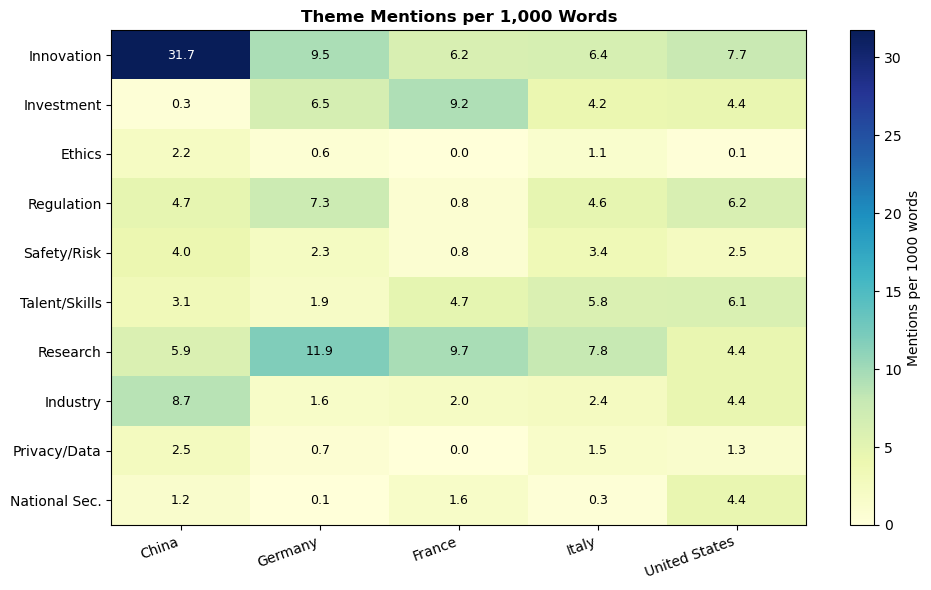

In [16]:
# Heatmap of normalized theme presence
outputs_dir = repo_root / 'outputs'
outputs_dir.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(theme_norm.values, aspect='auto', cmap='YlGnBu')
ax.set_xticks(range(len(countries)))
ax.set_xticklabels(countries, rotation=20, ha='right')
ax.set_yticks(range(len(theme_norm.index)))
ax.set_yticklabels(theme_norm.index)
ax.set_title('Theme Mentions per 1,000 Words', fontweight='bold')

for i in range(len(theme_norm.index)):
    for j in range(len(countries)):
        v = theme_norm.values[i, j]
        ax.text(j, i, f'{v:.1f}', ha='center', va='center',
                fontsize=9, color='white' if v > theme_norm.values.max()*0.5 else 'black')

plt.colorbar(im, ax=ax, label='Mentions per 1000 words')
plt.tight_layout()
fig.savefig(outputs_dir / 'theme_mentions_per_1000_words.png', dpi=300, bbox_inches='tight')
plt.show()


## 10. Framing Keyword Analysis

Counts keywords associated with innovation-oriented and restriction/risk-oriented policy framing, then scores each strategy document by raw frequency, mentions per 1,000 words, and share of all framing keyword mentions.


In [17]:
FRAMING_KEYWORDS = {
    'Innovation-oriented': [
        'opportunity',
        'growth',
        'competitiveness',
        'innovation',
        'investment',
        'leadership',
        'acceleration',
    ],
    'Restriction/risk-oriented': [
        'risk',
        'safeguard',
        'restriction',
        'compliance',
        'constraint',
    ],
}


def count_exact_keyword(text: str, keyword: str) -> int:
    """Count case-insensitive whole-word keyword mentions."""
    pattern = rf"\b{re.escape(keyword.lower())}\b"
    return len(re.findall(pattern, text.lower()))


framing_keyword_records = []
for country in countries:
    for framing, keywords in FRAMING_KEYWORDS.items():
        for keyword in keywords:
            framing_keyword_records.append({
                'Country': country,
                'Framing': framing,
                'Keyword': keyword,
                'Count': count_exact_keyword(texts[country], keyword),
            })

framing_keyword_counts = pd.DataFrame(framing_keyword_records)
framing_keyword_matrix = framing_keyword_counts.pivot_table(
    index=['Framing', 'Keyword'],
    columns='Country',
    values='Count',
    aggfunc='sum',
    fill_value=0,
)[countries]

framing_category_counts = framing_keyword_counts.pivot_table(
    index='Country',
    columns='Framing',
    values='Count',
    aggfunc='sum',
    fill_value=0,
).reindex(countries)

framing_scores_per_1000 = (
    framing_category_counts.div(word_counts, axis=0) * 1000
).round(2)

framing_share = framing_category_counts.div(
    framing_category_counts.sum(axis=1).replace(0, np.nan),
    axis=0,
).fillna(0).round(3)

framing_scores = pd.concat(
    {
        'raw_count': framing_category_counts,
        'per_1000_words': framing_scores_per_1000,
        'share_of_framing_mentions': framing_share,
    },
    axis=1,
)

print('Keyword counts by framing:')
display(framing_keyword_matrix)

print('\nDocument framing scores:')
display(framing_scores)


Keyword counts by framing:


Country                                    China  Germany  France  Italy  \
Framing                   Keyword                                          
Innovation-oriented       acceleration         0        1       2      3   
                          competitiveness      4        8       1     14   
                          growth               1        3       6      7   
                          innovation          49       35      13     33   
                          investment           0        2      23      4   
                          leadership           2        1       1      0   
                          opportunity          3        2       2      5   
Restriction/risk-oriented compliance           0        4       0     11   
                          constraint           0        0       0      0   
                          restriction          0        0       0      0   
                          risk                 1        1       0     27   
                          safeguard            0        0       0      0   

Country                                    United States  
Framing                   Keyword                         
Innovation-oriented       acceleration                 0  
                          competitiveness              1  
                          growth                       1  
                          innovation                  23  
                          investment                  10  
                          leadership                   7  
                          opportunity                  4  
Restriction/risk-oriented compliance                   2  
                          constraint                   0  
                          restriction                  0  
                          risk                         7  
                          safeguard                    1


Document framing scores:


raw_count                            \
Framing       Innovation-oriented Restriction/risk-oriented   
Country                                                       
China                          59                         1   
Germany                        52                         5   
France                         48                         0   
Italy                          66                        38   
United States                  46                        10   

                   per_1000_words                            \
Framing       Innovation-oriented Restriction/risk-oriented   
Country                                                       
China                       18.36                      0.31   
Germany                      4.48                      0.43   
France                       9.86                      0.00   
Italy                        4.42                      2.55   
United States                5.93                      1.29   

              share_of_framing_mentions                            
Framing             Innovation-oriented Restriction/risk-oriented  
Country                                                            
China                             0.983                     0.017  
Germany                           0.912                     0.088  
France                            1.000                     0.000  
Italy                             0.635                     0.365  
United States                     0.821                     0.179

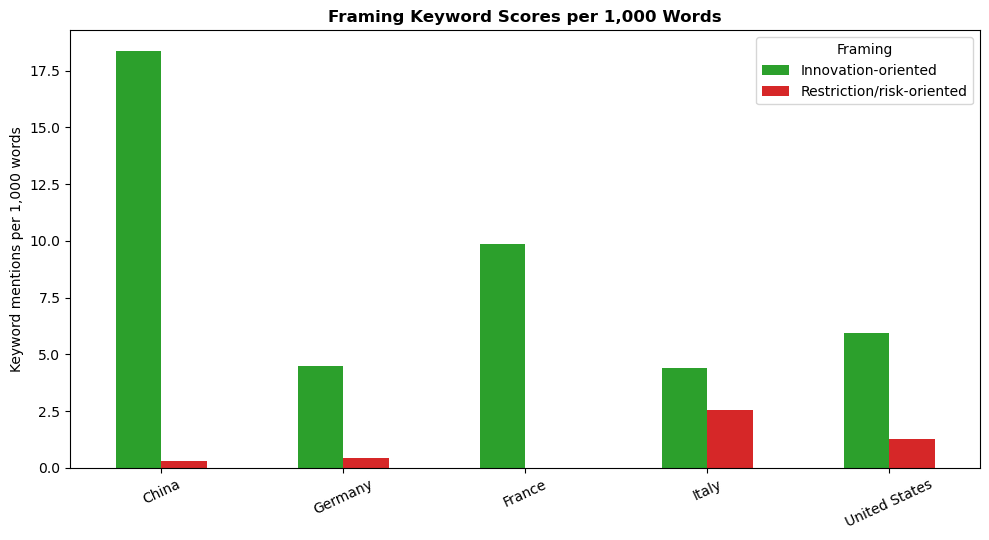

In [18]:
outputs_dir = repo_root / 'outputs'
outputs_dir.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(10, 5.5))
framing_scores_per_1000.plot(
    kind='bar',
    ax=ax,
    color=['#2ca02c', '#d62728'],
)
ax.set_title('Framing Keyword Scores per 1,000 Words', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Keyword mentions per 1,000 words')
ax.tick_params(axis='x', rotation=25)
ax.legend(title='Framing', loc='upper right')
plt.tight_layout()
fig.savefig(outputs_dir / 'framing_keyword_scores_per_1000_words.png', dpi=300, bbox_inches='tight')
plt.show()


## 11. Keyword Heatmap

Visualize how often each framing keyword appears in each national AI strategy document.

In [ ]:
import seaborn as sns

outputs_dir = repo_root / 'outputs'
outputs_dir.mkdir(parents=True, exist_ok=True)

keyword_heatmap = framing_keyword_counts.pivot_table(
    index='Keyword',
    columns='Country',
    values='Count',
    aggfunc='sum',
    fill_value=0,
).reindex(
    [kw for keywords in FRAMING_KEYWORDS.values() for kw in keywords]
)[countries]

fig, ax = plt.subplots(figsize=(11, 6.5))
sns.heatmap(
    keyword_heatmap,
    annot=True,
    fmt='d',
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Keyword count'},
    ax=ax,
)
ax.set_title('Framing Keyword Frequency by Country', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Keyword')
plt.tight_layout()
fig.savefig(outputs_dir / 'framing_keyword_frequency_by_country.png', dpi=300, bbox_inches='tight')
plt.show()


## 12. Country → Framing → Keyword Sankey

Trace each country's keyword mentions into framing categories and then into the specific keywords driving each frame.

In [ ]:
import plotly.graph_objects as go

sankey_rows = framing_keyword_counts[framing_keyword_counts['Count'] > 0].copy()

country_nodes = countries
framing_nodes = list(FRAMING_KEYWORDS.keys())
keyword_nodes = [kw for keywords in FRAMING_KEYWORDS.values() for kw in keywords]
node_labels = country_nodes + framing_nodes + keyword_nodes
node_index = {label: i for i, label in enumerate(node_labels)}

sources = []
targets = []
values = []
link_colors = []

for country in countries:
    for framing in framing_nodes:
        count = int(framing_category_counts.loc[country, framing])
        if count > 0:
            sources.append(node_index[country])
            targets.append(node_index[framing])
            values.append(count)
            link_colors.append('rgba(80, 80, 80, 0.22)')

framing_colors = {
    'Innovation-oriented': 'rgba(44, 160, 44, 0.35)',
    'Restriction/risk-oriented': 'rgba(214, 39, 40, 0.35)',
}
for _, row in sankey_rows.iterrows():
    sources.append(node_index[row['Framing']])
    targets.append(node_index[row['Keyword']])
    values.append(int(row['Count']))
    link_colors.append(framing_colors[row['Framing']])

node_colors = []
for label in node_labels:
    if label in COLORS:
        node_colors.append(COLORS[label])
    elif label == 'Innovation-oriented':
        node_colors.append('#2ca02c')
    elif label == 'Restriction/risk-oriented':
        node_colors.append('#d62728')
    else:
        node_colors.append('#9edae5')

sankey_fig = go.Figure(data=[go.Sankey(
    arrangement='snap',
    node=dict(
        pad=18,
        thickness=16,
        line=dict(color='rgba(0,0,0,0.25)', width=0.5),
        label=node_labels,
        color=node_colors,
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values,
        color=link_colors,
    ),
)])

sankey_fig.update_layout(
    title_text='Country → Framing → Keyword Mentions',
    font_size=11,
    height=650,
    margin=dict(l=20, r=20, t=60, b=20),
)
sankey_fig.show()


## 13. Sentence Explorer

Find the original sentences where each framing keyword appears. Use the widgets to filter by country, framing category, and keyword.

In [ ]:
from html import escape
from IPython.display import HTML

try:
    import ipywidgets as widgets
except ImportError:
    widgets = None


def split_sentences(text: str) -> list:
    cleaned = re.sub(r'\s+', ' ', text).strip()
    sentences = re.split(r'(?<=[.!?。！？])\s+', cleaned)
    return [s.strip() for s in sentences if len(s.strip()) > 20]


def highlight_keyword(sentence: str, keyword: str) -> str:
    escaped_sentence = escape(sentence)
    pattern = re.compile(rf'\b({re.escape(keyword)})\b', flags=re.IGNORECASE)
    return pattern.sub(r'<mark>\1</mark>', escaped_sentence)


sentence_records = []
for country, text in texts.items():
    for sentence in split_sentences(text):
        for framing, keywords in FRAMING_KEYWORDS.items():
            for keyword in keywords:
                if count_exact_keyword(sentence, keyword) > 0:
                    sentence_records.append({
                        'Country': country,
                        'Framing': framing,
                        'Keyword': keyword,
                        'Sentence': sentence,
                    })

keyword_sentence_matches = pd.DataFrame(sentence_records)
print(f'Keyword sentence matches: {len(keyword_sentence_matches)}')
display(keyword_sentence_matches.head(10))


def get_keyword_sentences(country='All', framing='All', keyword='All', max_results=25):
    df = keyword_sentence_matches.copy()
    if country != 'All':
        df = df[df['Country'] == country]
    if framing != 'All':
        df = df[df['Framing'] == framing]
    if keyword != 'All':
        df = df[df['Keyword'] == keyword]
    return df.head(max_results).reset_index(drop=True)


def show_keyword_sentences(country='All', framing='All', keyword='All', max_results=25):
    df = get_keyword_sentences(country, framing, keyword, max_results)
    if df.empty:
        display(HTML('<p>No matching sentences found.</p>'))
        return

    rows = []
    for _, row in df.iterrows():
        highlighted = highlight_keyword(row['Sentence'], row['Keyword'])
        rows.append(
            '<tr>'
            f'<td>{escape(row["Country"])}</td>'
            f'<td>{escape(row["Framing"])}</td>'
            f'<td>{escape(row["Keyword"])}</td>'
            f'<td>{highlighted}</td>'
            '</tr>'
        )

    table_rows = ''.join(rows)
    html = f"""
    <style>
      .sentence-table {{ border-collapse: collapse; width: 100%; font-size: 13px; }}
      .sentence-table th, .sentence-table td {{ border: 1px solid #ddd; padding: 7px; vertical-align: top; }}
      .sentence-table th {{ background: #f3f4f6; text-align: left; }}
      .sentence-table mark {{ background: #fff3a3; padding: 0 2px; }}
    </style>
    <table class="sentence-table">
      <thead><tr><th>Country</th><th>Framing</th><th>Keyword</th><th>Sentence</th></tr></thead>
      <tbody>{table_rows}</tbody>
    </table>
    """
    display(HTML(html))


if widgets is not None:
    country_dropdown = widgets.Dropdown(options=['All'] + countries, value='All', description='Country')
    framing_dropdown = widgets.Dropdown(options=['All'] + list(FRAMING_KEYWORDS.keys()), value='All', description='Framing')
    keyword_dropdown = widgets.Dropdown(
        options=['All'] + [kw for keywords in FRAMING_KEYWORDS.values() for kw in keywords],
        value='All',
        description='Keyword',
    )
    max_slider = widgets.IntSlider(value=25, min=5, max=100, step=5, description='Rows')
    output = widgets.Output()

    def refresh_sentences(*_):
        with output:
            output.clear_output(wait=True)
            show_keyword_sentences(
                country_dropdown.value,
                framing_dropdown.value,
                keyword_dropdown.value,
                max_slider.value,
            )

    for control in [country_dropdown, framing_dropdown, keyword_dropdown, max_slider]:
        control.observe(refresh_sentences, names='value')

    display(widgets.VBox([
        widgets.HBox([country_dropdown, framing_dropdown, keyword_dropdown, max_slider]),
        output,
    ]))
    refresh_sentences()
else:
    show_keyword_sentences(max_results=25)


## 14. Bigram Analysis — Top Phrases per Country


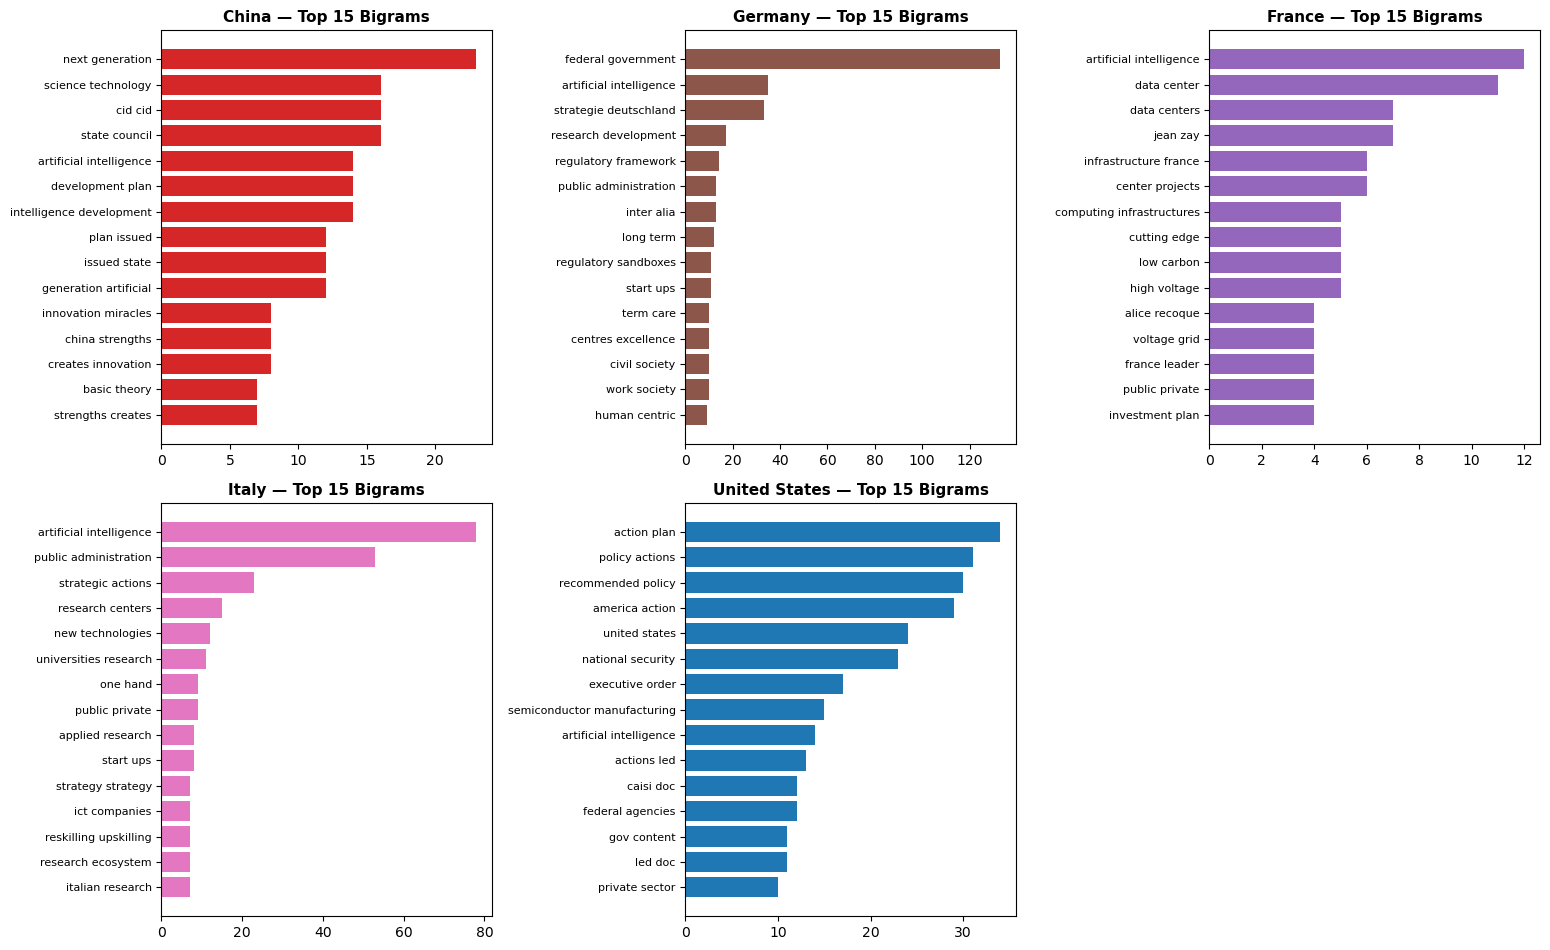

In [19]:
bg_vec = CountVectorizer(
    stop_words=list(ALL_STOP),
    token_pattern=r"[a-zA-Zà-ÿÀ-ÝäöüÄÖÜß']{3,}",
    ngram_range=(2, 2),
    max_features=2000,
)
bg = bg_vec.fit_transform(docs)
bg_vocab = bg_vec.get_feature_names_out()

fig, axes = country_subplot_grid(len(countries), n_cols=3)
for ax, (i, country) in zip(axes, enumerate(countries)):
    row = bg[i].toarray().flatten()
    top_idx = row.argsort()[-15:][::-1]
    phrases = [bg_vocab[j] for j in top_idx][::-1]
    counts = [row[j] for j in top_idx][::-1]
    ax.barh(phrases, counts, color=COLORS[country])
    ax.set_title(f'{country} — Top 15 Bigrams', fontsize=11, fontweight='bold')
    ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()


## 15. Topic Modeling (LDA)

Discover latent topics across all 4 documents.


In [20]:
# CountVectorizer for LDA
ct_vec = CountVectorizer(
    stop_words=list(ALL_STOP),
    token_pattern=r"[a-zA-Zà-ÿÀ-ÝäöüÄÖÜß']{3,}",
    max_features=1500,
    min_df=2,
    max_df=0.95,
)
ct = ct_vec.fit_transform(docs)
ct_vocab = ct_vec.get_feature_names_out()

n_topics = 4
lda = LatentDirichletAllocation(n_components=n_topics, random_state=42, max_iter=20)
doc_topic = lda.fit_transform(ct)

# Print top words per topic
print('Top words per topic:')
for i, topic in enumerate(lda.components_):
    top_words_topic = [ct_vocab[j] for j in topic.argsort()[-12:][::-1]]
    print(f'  Topic {i+1}: {", ".join(top_words_topic)}')

print()
topic_df = pd.DataFrame(doc_topic.round(3), index=countries,
                        columns=[f'Topic {i+1}' for i in range(n_topics)])
print('Topic distribution per document:')
display(topic_df)


Top words per topic:
  Topic 1: actions, systems, administration, specific, action, federal, america, initiatives, led, adoption, digital, act
  Topic 2: france, french, billion, investment, europe, european, researchers, power, sites, since, partnership, million
  Topic 3: set, intelligent, social, basic, theory, issued, carry, plans, programs, creates, strengths, promote
  Topic 4: federal, funding, germany, systems, european, further, society, german, digital, mobility, regulatory, instance

Topic distribution per document:


,Topic 1,Topic 2,Topic 3,Topic 4
China,0.0,0.0,0.999,0.0
Germany,0.0,0.0,0.000,1.0
France,0.0,1.0,0.000,0.0
Italy,1.0,0.0,0.000,0.0
United States,1.0,0.0,0.000,0.0


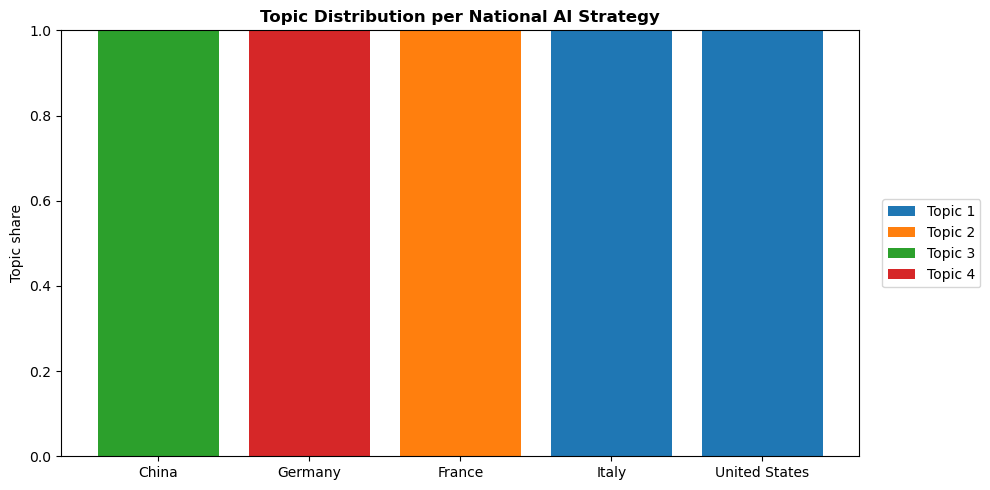

In [21]:
# Stacked bar of topic distribution
fig, ax = plt.subplots(figsize=(10, 5))
bottom = np.zeros(len(countries))
topic_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
for i in range(n_topics):
    vals = topic_df[f'Topic {i+1}'].values
    ax.bar(countries, vals, bottom=bottom, label=f'Topic {i+1}', color=topic_colors[i])
    bottom += vals

ax.set_ylabel('Topic share')
ax.set_title('Topic Distribution per National AI Strategy', fontweight='bold')
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
plt.show()


## 16. Save Cleaned Texts and Stats

In [22]:
out_dir = repo_root / 'data' / 'pdf' / 'AI Policy' / '_extracted'
out_dir.mkdir(parents=True, exist_ok=True)

for country, text in texts.items():
    (out_dir / f'{country}.txt').write_text(text, encoding='utf-8')

stats_df.to_csv(out_dir / 'document_stats.csv')
theme_counts.to_csv(out_dir / 'theme_counts_raw.csv')
theme_norm.to_csv(out_dir / 'theme_per_1000_words.csv')
sim_df.to_csv(out_dir / 'similarity_matrix.csv')
framing_keyword_counts.to_csv(out_dir / 'framing_keyword_counts.csv', index=False)
framing_category_counts.to_csv(out_dir / 'framing_category_counts.csv')
framing_scores_per_1000.to_csv(out_dir / 'framing_scores_per_1000_words.csv')
framing_share.to_csv(out_dir / 'framing_share_of_mentions.csv')
keyword_sentence_matches.to_csv(out_dir / 'keyword_sentence_matches.csv', index=False)

print(f'Saved outputs to: {out_dir}')
for f in sorted(out_dir.iterdir()):
    print(f'  - {f.name}')


Saved outputs to: /home/wucheng/AI-Policy/data/pdf/AI Policy/_extracted
  - China.txt
  - France.txt
  - Germany.txt
  - Italy.txt
  - United States.txt
  - document_stats.csv
  - framing_category_counts.csv
  - framing_keyword_counts.csv
  - framing_scores_per_1000_words.csv
  - framing_share_of_mentions.csv
  - similarity_matrix.csv
  - theme_counts_raw.csv
  - theme_per_1000_words.csv


## What Else Can You Do?

- **Sentence-level extraction** — pull sentences mentioning specific themes for qualitative review
- **Named entity recognition** (spaCy) — extract organizations, locations, numbers
- **Sentiment analysis** — tone of policy language (more useful with multilingual models)
- **Cross-language alignment** — translate to one language first (DeepL / Google Translate API) for stronger comparison
- **Time-aware analysis** — if you have multiple versions per country (e.g. 2018 vs 2023), track wording changes
- **Citation-style network** — extract references and build a graph of who cites whom
